In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [39]:
df = pd.read_csv(
    "Diwali Sales Data.csv",
    encoding="latin1"
)

In [40]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [41]:
df.shape

(11251, 15)

In [42]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='str')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [44]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(8)

In [46]:
df.drop_duplicates(inplace=True)

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11243
unnamed1            11243
dtype: int64

In [49]:
df.dropna(subset=['Amount'], inplace=True)

In [50]:
df.shape

(11231, 15)

In [51]:
df.columns = df.columns.str.strip()

In [52]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='str')

In [53]:
df.dtypes

User_ID               int64
Cust_name               str
Product_ID              str
Gender                  str
Age Group               str
Age                   int64
Marital_Status        int64
State                   str
Zone                    str
Occupation              str
Product_Category        str
Orders                int64
Amount              float64
Status              float64
unnamed1            float64
dtype: object

In [54]:
df['Amount'] = df['Amount'].astype(int)

In [55]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,17,25,35,45,55,100],
    labels=[
        '0-17',
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '55+'
    ]
)

In [56]:
df[['Age','Age_Group']].head()

,Age,Age_Group
0,28,26-35
1,35,26-35
2,35,26-35
3,16,0-17
4,28,26-35


In [57]:
df['Gender'].value_counts()

Gender
F    7828
M    3403
Name: count, dtype: int64

In [58]:
gender_sales = df.groupby('Gender')['Amount'].sum()

gender_sales

Gender
F    74307679
M    31871146
Name: Amount, dtype: int64

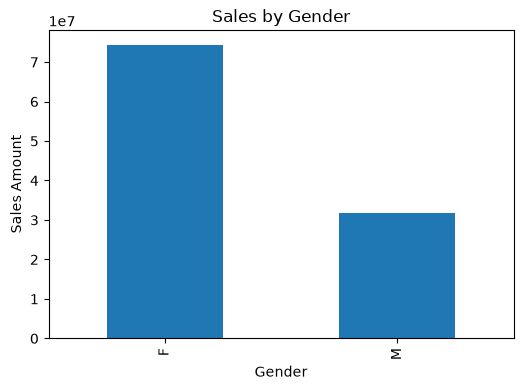

In [59]:
plt.figure(figsize=(6,4))

gender_sales.plot(kind='bar')

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales Amount")

plt.show()

In [60]:
age_sales = (
    df.groupby('Age_Group')['Amount']
    .sum()
)

age_sales

Age_Group
0-17      2699653
18-25    17235530
26-35    42820914
36-45    21895988
46-55    17445753
55+       4080987
Name: Amount, dtype: int64

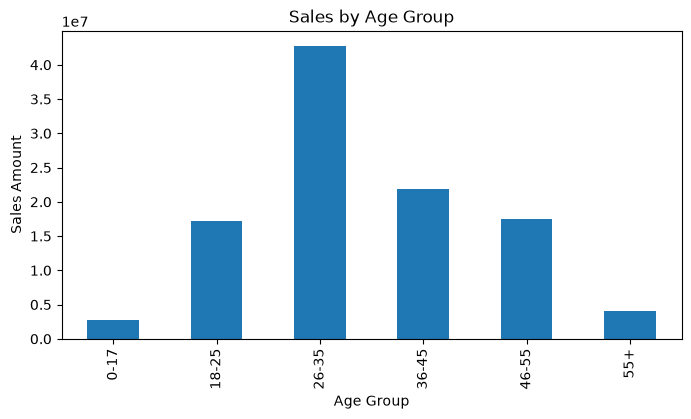

In [61]:
plt.figure(figsize=(8,4))

age_sales.plot(kind='bar')

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales Amount")

plt.show()

In [62]:
state_sales = (
    df.groupby('State')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sales

State
Uttar Pradesh       19346055
Maharashtra         14404467
Karnataka           13523540
Delhi               11603818
Madhya Pradesh       8101142
Andhra Pradesh       8037146
Himachal Pradesh     4963368
Haryana              4217871
Bihar                4014669
Gujarat              3938159
Name: Amount, dtype: int64

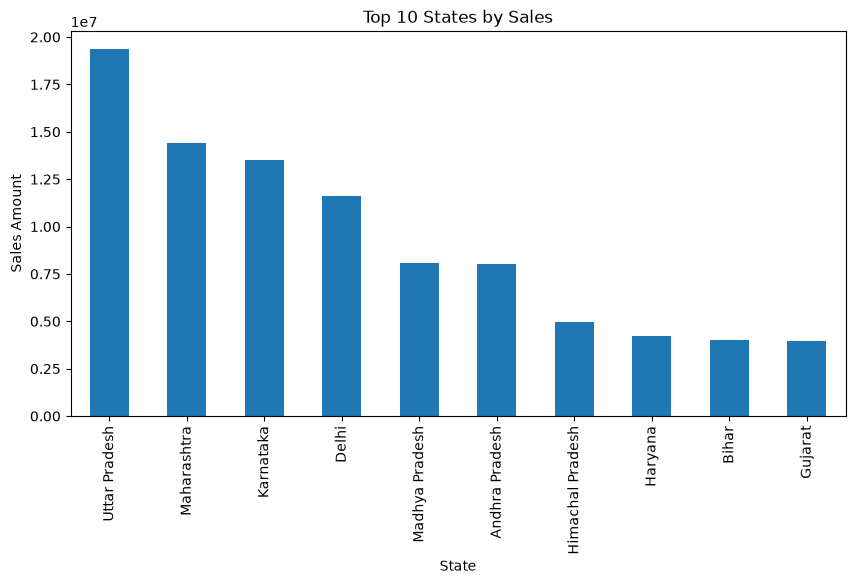

In [63]:
plt.figure(figsize=(10,5))

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")

plt.ylabel("Sales Amount")

plt.show()

In [64]:
category_sales = (
    df.groupby('Product_Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product_Category
Food                     33933883
Clothing & Apparel       16484472
Electronics & Gadgets    15607657
Footwear & Shoes         15575209
Furniture                 5440051
Games & Toys              4331694
Sports Products           3635933
Beauty                    1959484
Auto                      1935041
Stationery                1676051
Household items           1569337
Tupperware                1155642
Books                     1061478
Decor                      730360
Pet Care                   482277
Hand & Power Tools         405618
Veterinary                 112702
Office                      81936
Name: Amount, dtype: int64

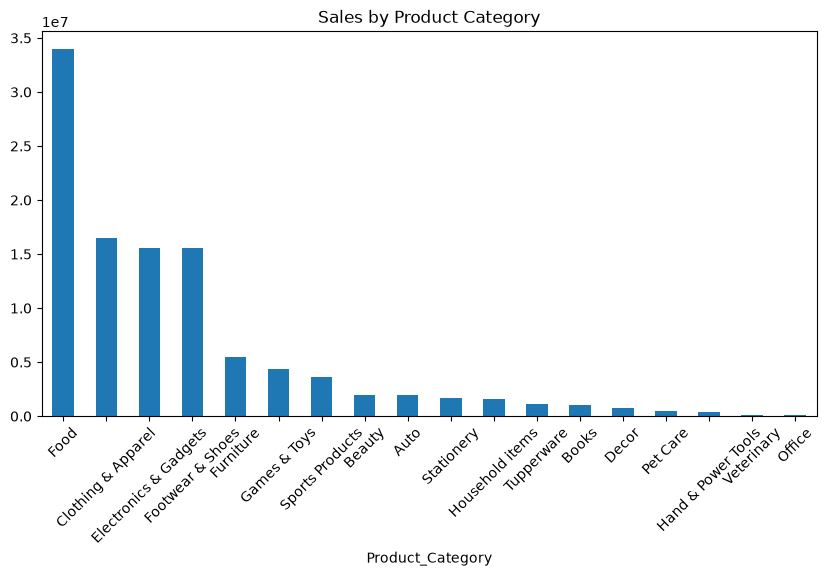

In [65]:
plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Sales by Product Category")

plt.xticks(rotation=45)

plt.show()

In [66]:
occupation_sales = (
    df.groupby('Occupation')['Amount']
    .sum()
    .sort_values(ascending=False)
)

occupation_sales.head(10)

Occupation
IT Sector      14741862
Healthcare     13034586
Aviation       12599994
Banking        10770610
Govt            8517212
Hospitality     6337633
Media           6295832
Automobile      5368596
Chemical        5297436
Lawyer          4981665
Name: Amount, dtype: int64

In [67]:
product_orders = (
    df.groupby('Product_Category')['Orders']
    .sum()
    .sort_values(ascending=False)
)

product_orders

Product_Category
Clothing & Apparel       6627
Food                     6110
Electronics & Gadgets    5208
Footwear & Shoes         2646
Household items          1331
Beauty                   1086
Games & Toys              940
Furniture                 889
Sports Products           870
Pet Care                  536
Stationery                281
Office                    261
Books                     245
Auto                      238
Decor                     235
Veterinary                206
Tupperware                166
Hand & Power Tools         80
Name: Orders, dtype: int64

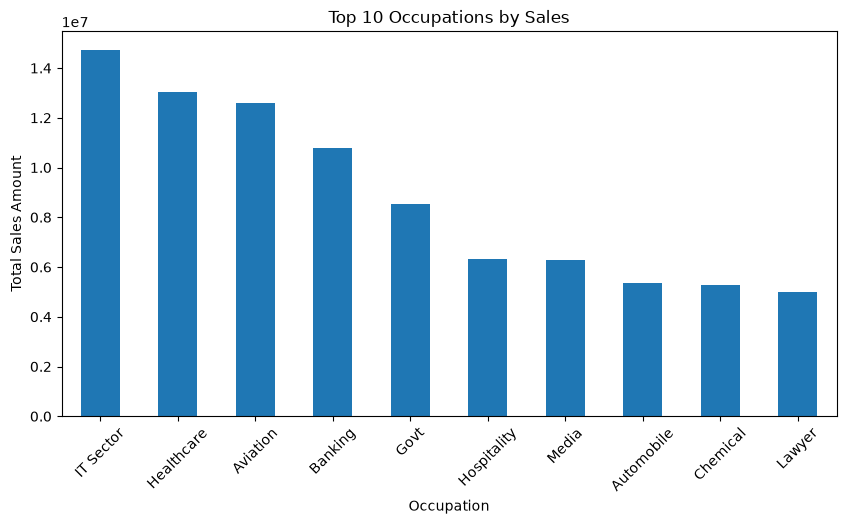

In [68]:
plt.figure(figsize=(10,5))

occupation_sales.head(10).plot(kind='bar')

plt.title("Top 10 Occupations by Sales")
plt.xlabel("Occupation")
plt.ylabel("Total Sales Amount")

plt.xticks(rotation=45)

plt.show()

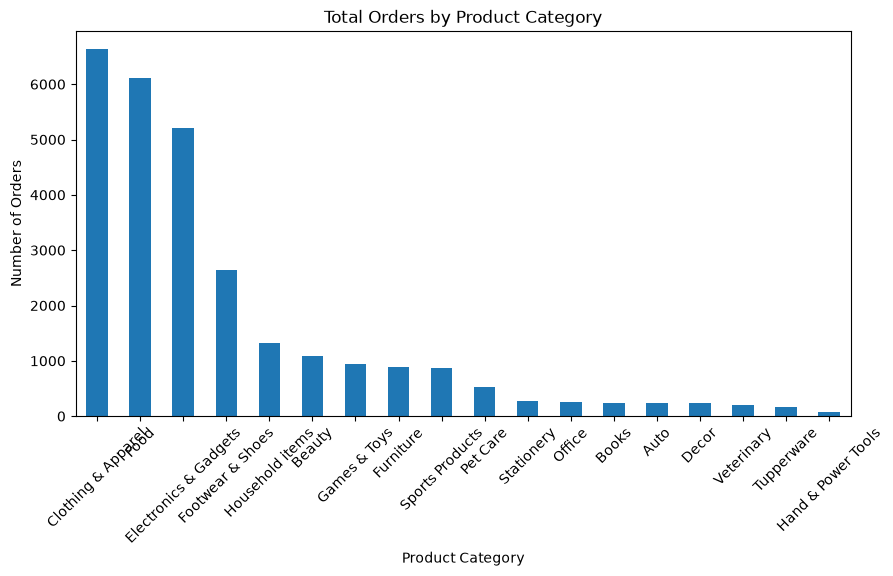

In [69]:
plt.figure(figsize=(10,5))

product_orders.plot(kind='bar')

plt.title("Total Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

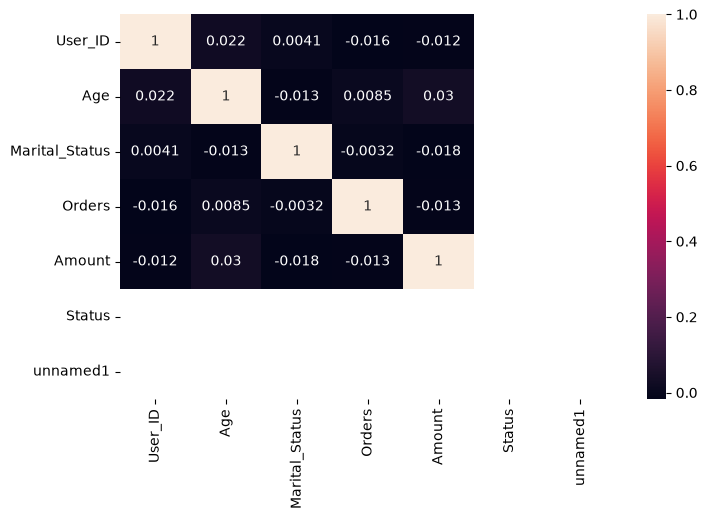

In [70]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

In [71]:
df.to_csv(
    "Diwali_Cleaned_Data.csv",
    index=False
)

In [72]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1', 'Age_Group'],
      dtype='str')

In [73]:
df.drop(columns=['Age Group'], inplace=True)

In [74]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age', 'Marital_Status',
       'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount',
       'Status', 'unnamed1', 'Age_Group'],
      dtype='str')

In [75]:
df.to_csv(
    "Diwali_Cleaned_Data.csv",
    index=False
)

PermissionError: [Errno 13] Permission denied: 'Diwali_Cleaned_Data.csv'

In [76]:
df.to_csv(
    "Diwali_Cleaned1_Data.csv",
    index=False
)